# **Dataset Overview**

The dataset used in this analysis is the Boston Housing dataset, which contains 506 observations across 14 columns. Among these, 13 columns are predictor variables (e.g., CRIM, ZN, RM, AGE, TAX, LSTAT, etc.), while the target variable is MEDV (Median value of owner-occupied homes).

Data Types: 12 float variables and 2 integer variables (CHAS, RAD).

Missing Values: None detected.

Feature Relevance: Predictors represent socio-economic, demographic, and housing-related characteristics.

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("fedesoriano/the-boston-houseprice-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'the-boston-houseprice-data' dataset.
Path to dataset files: /kaggle/input/the-boston-houseprice-data


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline


In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('/root/.cache/kagglehub/datasets/fedesoriano/the-boston-houseprice-data/versions/1/boston.csv')
df.head()


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [5]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


In [6]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


# **Distribution Plots**

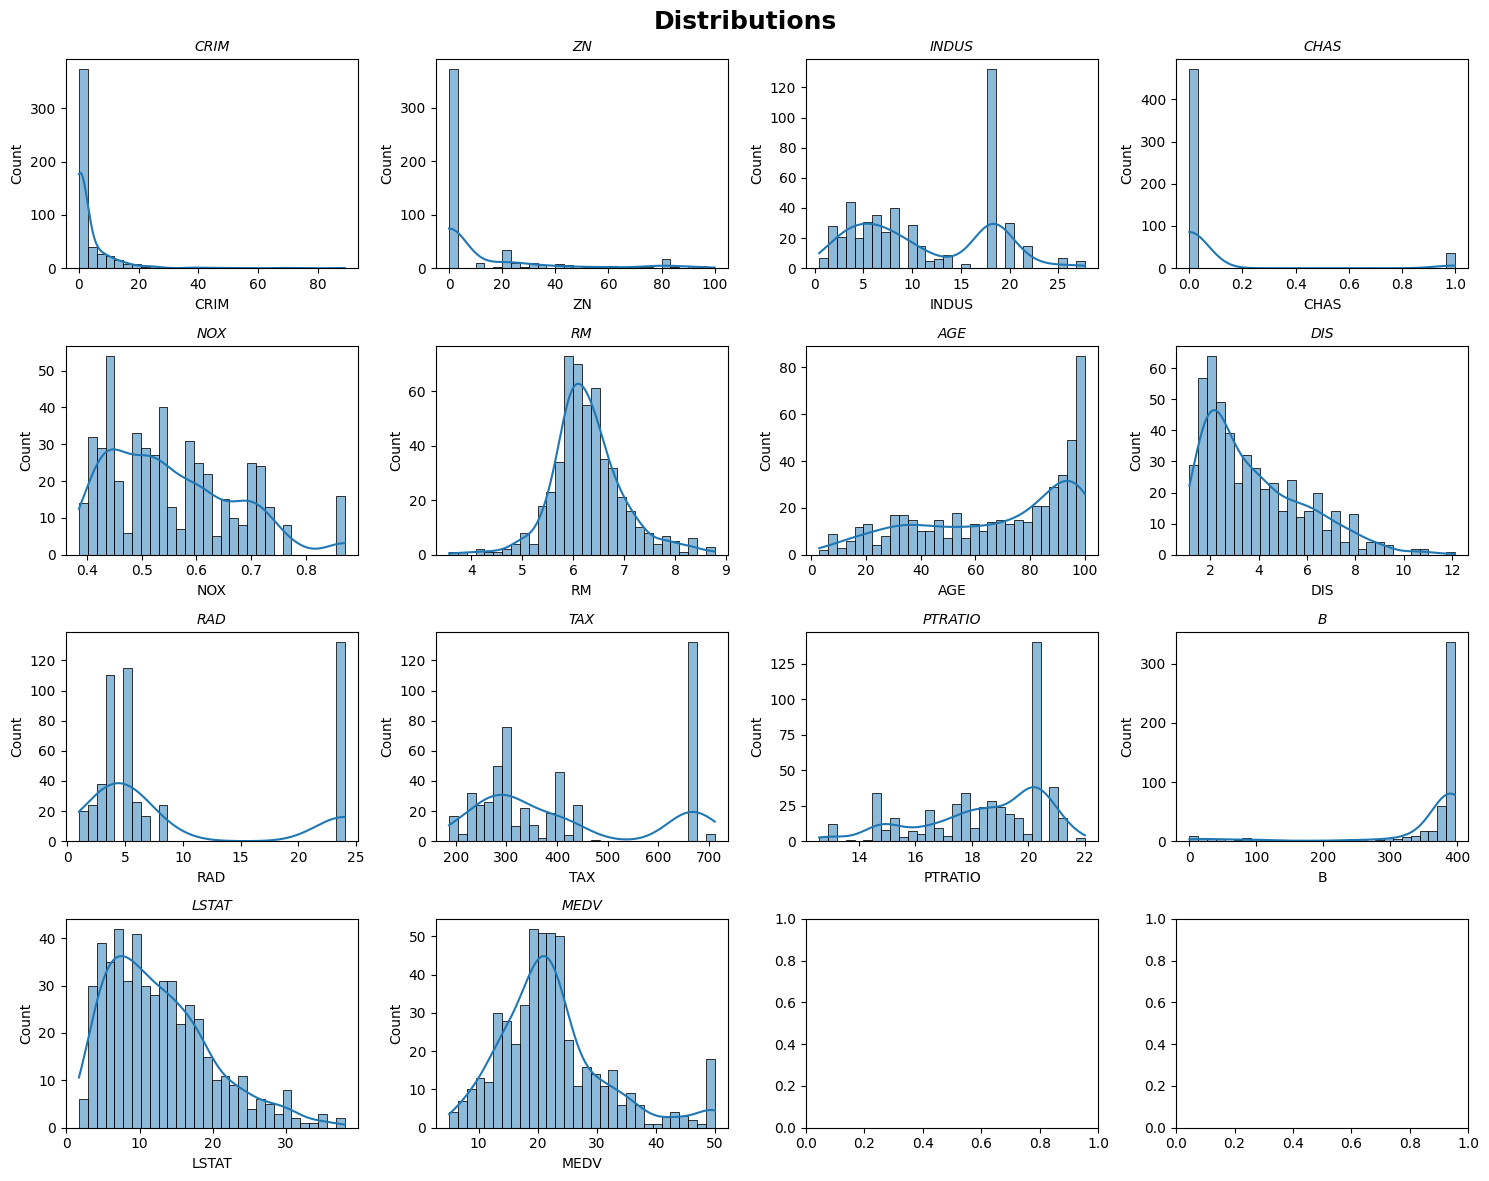

In [7]:
fig ,axes = plt.subplots(nrows = 4, ncols = 4, figsize =(15,12))
fig.suptitle("Distributions", fontsize = 18, fontweight = "bold")

for i, col in enumerate(df):
    row = i // 4
    col_idx = i % 4
    ax = axes[row,col_idx]
    sns.histplot(data = df, x =col , kde = True, ax =ax,bins=30)
    ax.set_title(col,fontsize = 10, fontstyle = "italic")
plt.tight_layout()
plt.show()

# **Outlier Detection with Boxplots**

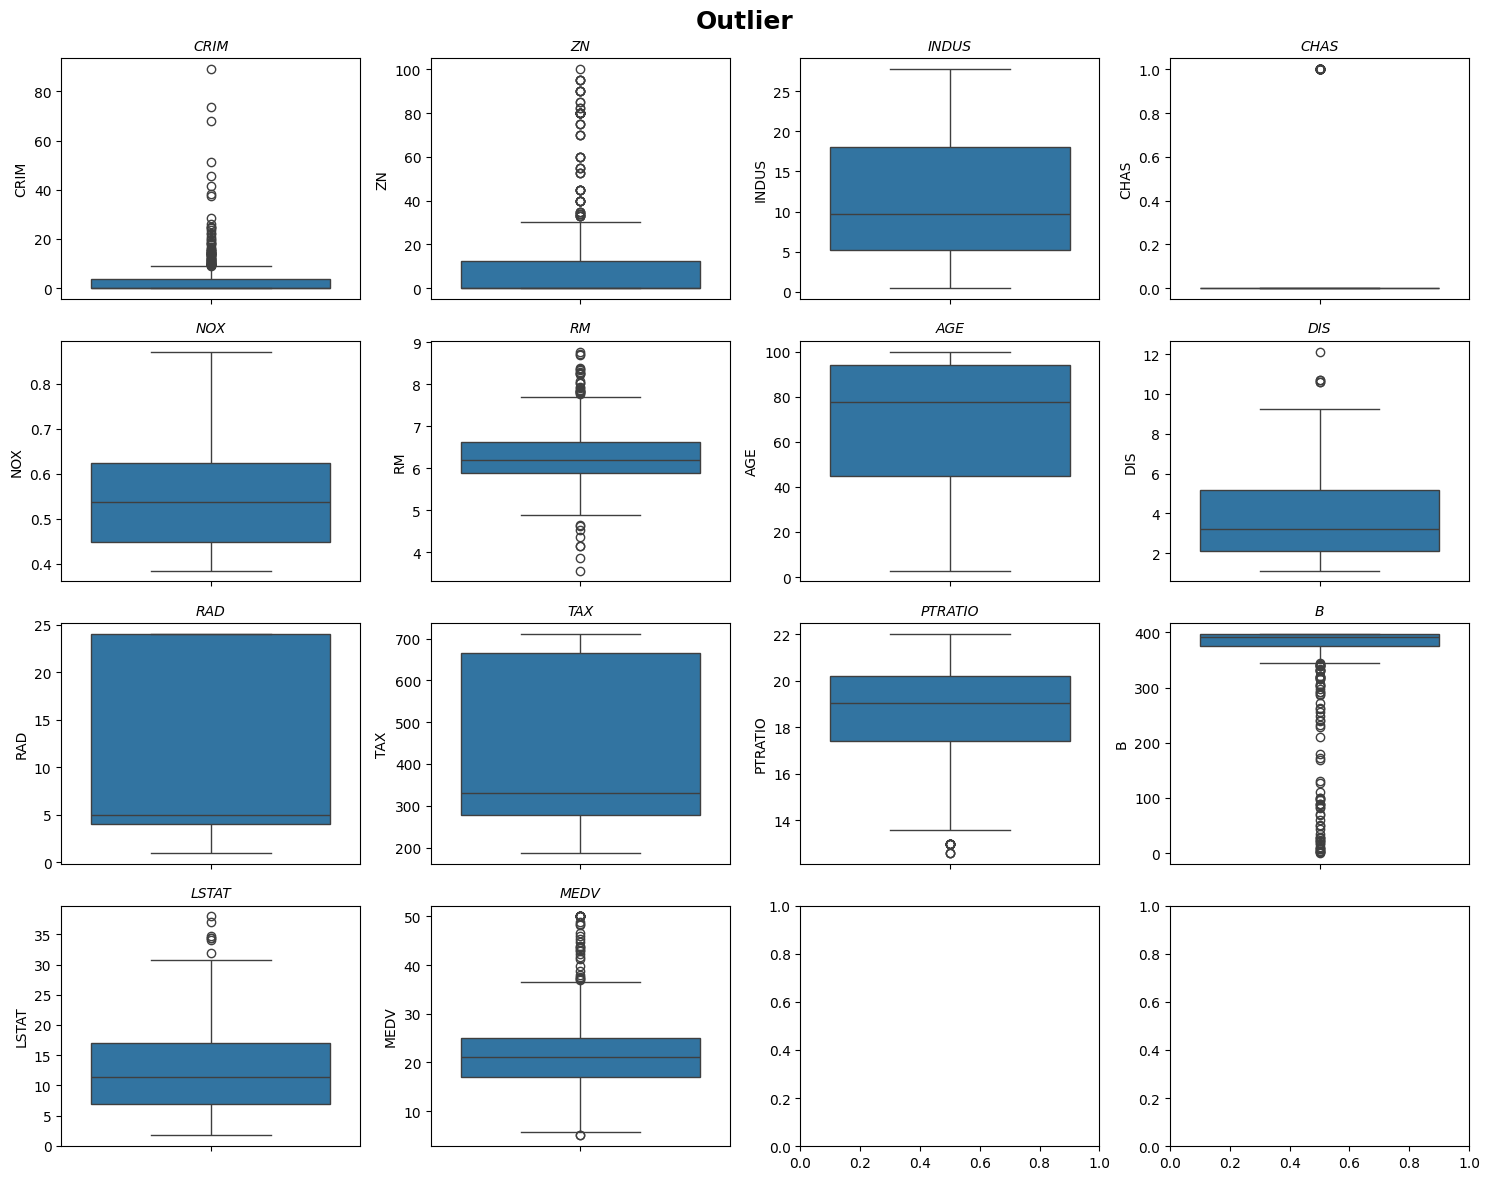

In [8]:
fig ,axes = plt.subplots(nrows = 4, ncols = 4, figsize =(15,12))
fig.suptitle("Outlier", fontsize = 18, fontweight = "bold")

for i, col in enumerate(df):
    row = i // 4
    col_idx = i % 4
    ax = axes[row,col_idx]
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col,fontsize = 10, fontstyle = "italic")
plt.tight_layout()
plt.show()

# **Outlier Summary using IQR**

In [10]:
def find_outliers_iqr(df,threshold = 1.5):
    outlier_summary = {}


    for col in df:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1- threshold * IQR
        upper_bound = Q3+ threshold * IQR

        outliers = df[ (df[col] < lower_bound) | (df[col] > upper_bound )]
        outlier_summary[col] = {
            "outlier_count": outliers.shape[0],
            "outiler_percentage": 100 * outliers.shape[0] / df.shape[0],
            "lower_bound": lower_bound,
            "upper_bound": upper_bound
        }
    return pd.DataFrame(outlier_summary)
find_outliers_iqr(df,2)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
outlier_count,50.000000,58.000000,0.00,35.000000,0.000,15.000000,0.000,1.000000,0.0,0.0,0.0,69.000000,2.000000,31.000000
outiler_percentage,9.881423,11.462451,0.00,6.916996,0.000,2.964427,0.000,0.197628,0.0,0.0,0.0,13.636364,0.395257,6.126482
lower_bound,-7.108030,-25.000000,-20.63,0.000000,0.099,4.409500,-53.075,-4.076325,-36.0,-495.0,11.8,333.682500,-13.060000,1.075000
upper_bound,10.867158,37.500000,43.92,0.000000,0.974,8.099500,192.175,11.364925,64.0,1440.0,25.8,437.920000,36.965000,40.950000


# **Scatter Plots vs Target (MEDV)**

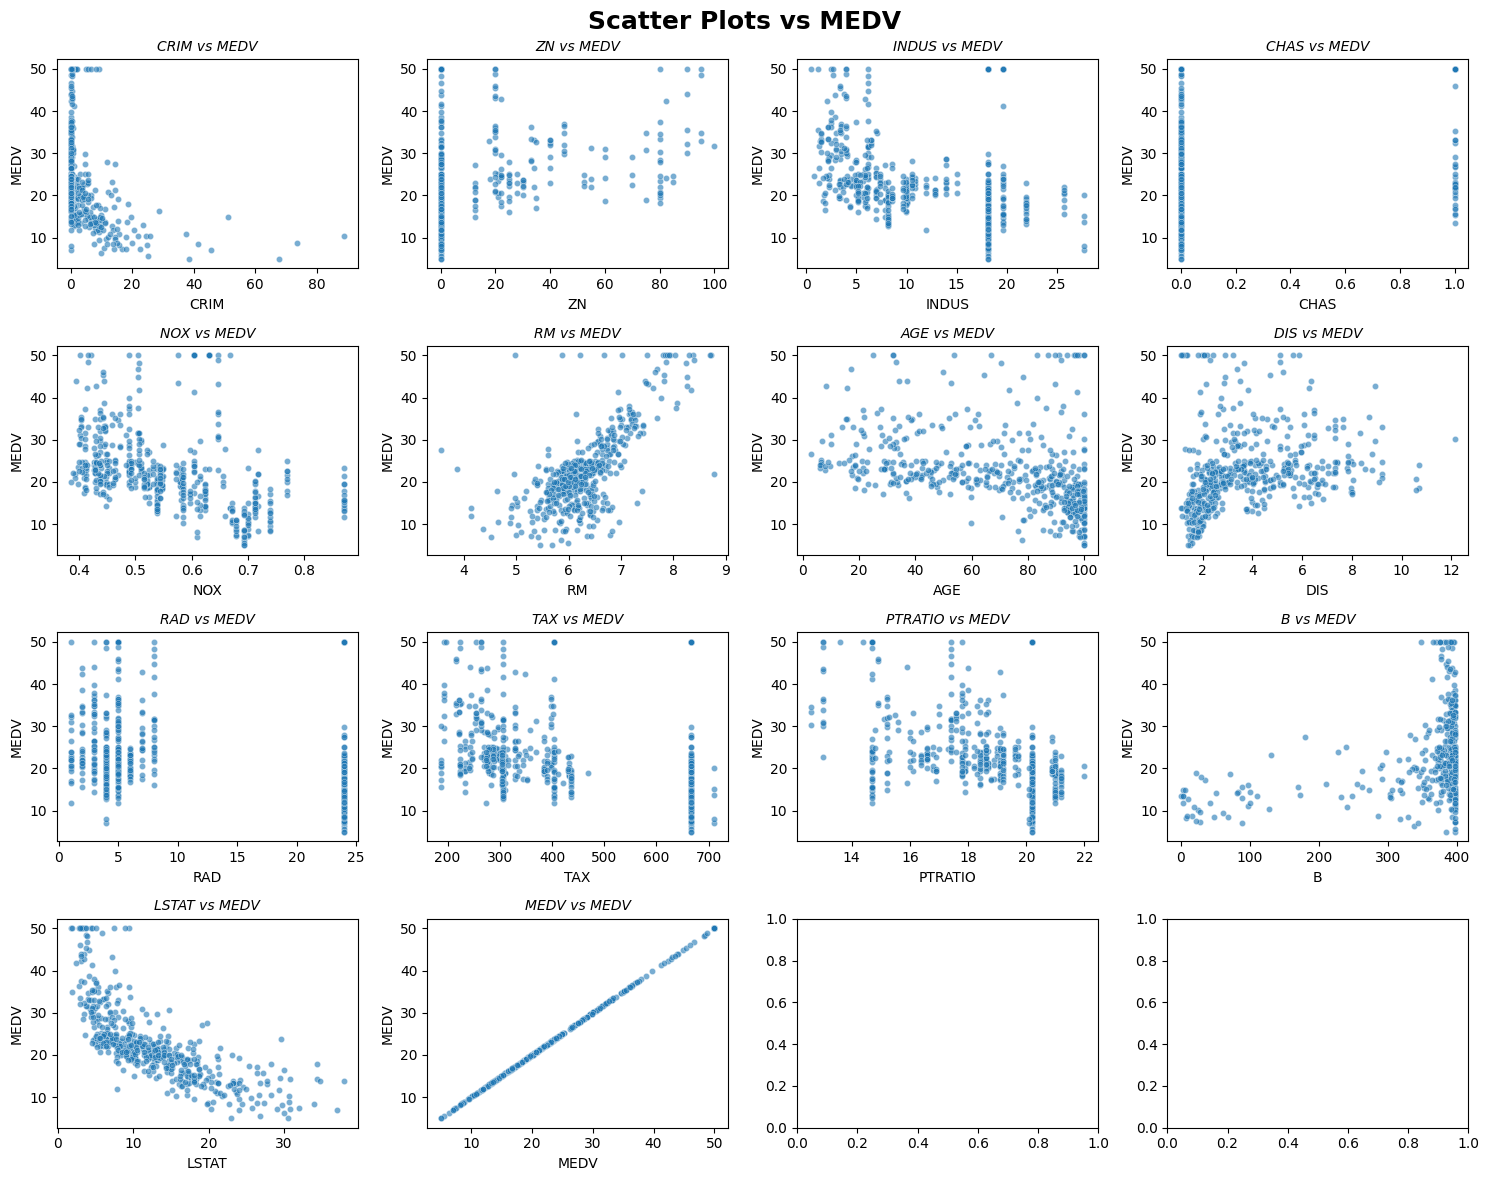

In [11]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(15,12))
fig.suptitle("Scatter Plots vs MEDV", fontsize=18, fontweight="bold")

for i, col in enumerate(df):
    row = i // 4
    col_idx = i % 4
    ax = axes[row, col_idx]
    sns.scatterplot(data=df, x=col, y="MEDV", ax=ax, s=20, alpha=0.6)
    ax.set_title(f"{col} vs MEDV", fontsize=10, fontstyle="italic")

plt.tight_layout()
plt.show()

# **Correlation Heatmap**

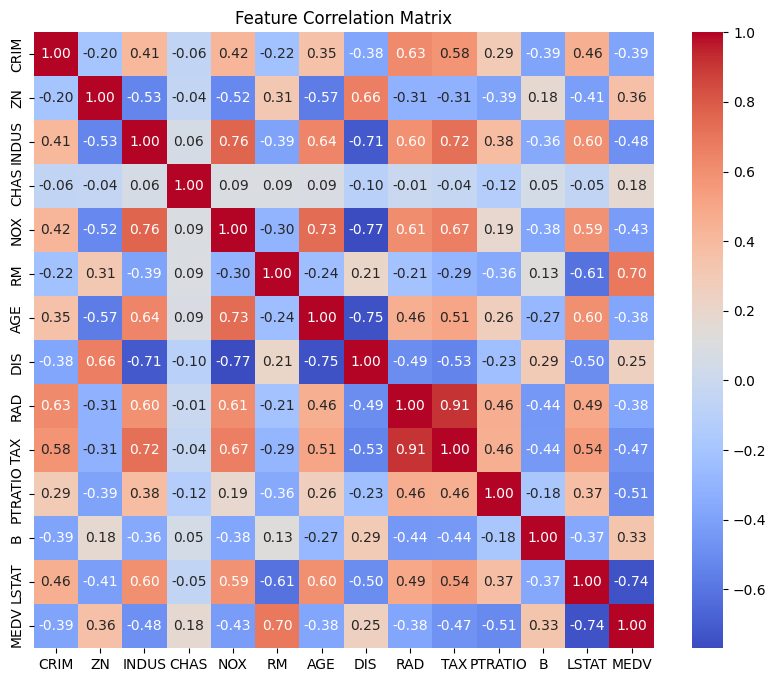

In [16]:
# Step 6: Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
target='MEDV'
x=df.drop(target,axis=1)
y=df[target]

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
scaler =StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


In [18]:
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error,mean_squared_error

In [15]:
def calculate_model_metrics(true,predicted):
    mae = mean_absolute_error(true,predicted)
    mse = mean_squared_error(true,predicted)
    rmse = np.sqrt(mean_squared_error(true,predicted))
    r2_square = r2_score(true,predicted)
    return mae,rmse,r2_square

In [20]:
models = {
    "LGBMRegressor": LGBMRegressor(verbose=-1),
    "XGBRegressor": XGBRegressor(),
    "GradientBoostingRegressor": GradientBoostingRegressor(),
    "RandomForestRegressor": RandomForestRegressor(),
    "DecisionTreeRegressor": DecisionTreeRegressor(),
    "SVR": SVR(),
    "ElasticNet": ElasticNet(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "LinearRegression": LinearRegression()
}

In [19]:
import pandas as pd
import IPython.display as display

results = []

for name, model in models.items():
    model.fit(x_train_scaled, y_train)

    y_train_pred = model.predict(x_train_scaled)
    y_test_pred = model.predict(x_test_scaled)

    model_train_mae, model_train_rmse, model_train_r2 = calculate_model_metrics(y_train, y_train_pred)
    model_test_mae, model_test_rmse, model_test_r2 = calculate_model_metrics(y_test, y_test_pred)

    results.append({
        "Model": name,
        "Train RMSE": model_train_rmse,
        "Train MAE": model_train_mae,
        "Train R²": model_train_r2,
        "Test RMSE": model_test_rmse,
        "Test MAE": model_test_mae,
        "Test R²": model_test_r2
    })


results_df = pd.DataFrame(results)

display.display(results_df)


,Model,Train RMSE,Train MAE,Train R²,Test RMSE,Test MAE,Test R²
0,LGBMRegressor,1.515522,0.932901,0.973561,2.827720,1.942053,0.890964
1,XGBRegressor,0.016189,0.011183,0.999997,2.628542,1.890887,0.905784
2,GradientBoostingRegressor,1.317140,1.043816,0.980030,2.508043,1.928095,0.914224
3,RandomForestRegressor,1.379304,0.888208,0.978101,3.065766,2.110902,0.871834
4,DecisionTreeRegressor,0.000000,0.000000,1.000000,3.144603,2.291176,0.865157
5,SVR,5.238364,2.993397,0.684133,5.066413,2.731716,0.649977
6,ElasticNet,5.433075,3.780608,0.660215,5.325284,3.431002,0.613294
7,Lasso,5.290949,3.682759,0.677759,5.251447,3.473770,0.623943
8,Ridge,4.652177,3.308708,0.750870,4.930812,3.185724,0.668462
9,LinearRegression,4.652033,3.314772,0.750886,4.928602,3.189092,0.668759


# **Model Performance and Dataset Analysis Report**


# **Models Evaluated**

The following regression models were trained and evaluated using scaled features (x_train_scaled, x_test_scaled):

Linear Regression

Ridge Regression

Lasso Regression

ElasticNet

Support Vector Regressor (SVR)

Decision Tree Regressor

Random Forest Regressor

Gradient Boosting Regressor

XGBoost Regressor

LightGBM Regressor

Performance was assessed using RMSE (Root Mean Squared Error), MAE (Mean Absolute Error), and R² Score on both the training and test sets.

# **Key Findings**

Among the models evaluated, the best performing approaches were Gradient Boosting Regressor (Test RMSE = 2.50, R² = 0.91), XGBoost Regressor (Test RMSE = 2.63, R² = 0.91), and LightGBM Regressor (Test RMSE = 2.82, R² = 0.89). These ensemble methods achieved the strongest results, demonstrating their ability to generalize well and effectively capture non-linear relationships within the data.

In contrast, the Decision Tree Regressor exhibited perfect performance on the training set (RMSE = 0.00, R² = 1.00) but showed weaker generalization on the test set (RMSE = 3.14, R² = 0.86), providing clear evidence of overfitting due to the absence of regularization. The linear models—Linear Regression and Ridge—achieved moderate predictive power with R² values around 0.67, while Lasso and ElasticNet performed weaker, indicating underfitting.

# **Conclusion**

The analysis demonstrates that ensemble learning methods—particularly Gradient Boosting, XGBoost, and LightGBM—provide the most accurate and reliable predictions for housing prices in the Boston dataset. While linear models offer interpretability, they fall short in predictive power. Decision Trees, though flexible, overfit without regularization.

Performance can be further improved through systematic hyperparameter tuning using techniques such as GridSearchCV or RandomizedSearchCV. Optimizing parameters such as learning rate, maximum depth, and number of estimators for ensemble methods; regularization terms for linear models

The target variable MEDV, which represents the median value of owner-occupied homes in Boston, is influenced by both housing characteristics and neighborhood socio-economic conditions. Features such as the average number of rooms (RM) show a strong positive correlation with housing prices, while the percentage of lower status population (LSTAT) and the pupil–teacher ratio (PTRATIO) are strongly negatively correlated with property values. The models developed in this study successfully captured these relationships, with ensemble methods such as Gradient Boosting, XGBoost, and LightGBM providing the most accurate predictions. This demonstrates that complex, non-linear interactions among features play an important role in explaining variations in MEDV. Ultimately, the analysis confirms that housing prices in Boston are determined not only by the structural attributes of homes but also by broader social and economic factors—patterns that advanced models can effectively capture and predict.